# A Python-Based Risk and Return Analysis of Selected Beauty Companies
## ACC102 Mini Assignment – Track 2
### Student: Yuntong.Bai

## 1. Introduction

### 1.1 Project Aim

This project aims to build a small Python-based risk and return comparison project for five beauty-related companies: Estée Lauder Companies, Coty Inc., Inter Parfums, Inc., e.l.f. Beauty, and Ulta Beauty. Using monthly stock data from WRDS, this project compares cumulative returns, average monthly returns, and volatility to evaluate historical risk-return differences across the selected companies.

### 1.2 Intended Users

The intended users are beginner-level investors, business students, and market researchers who want to compare selected beauty-related companies using basic stock performance indicators. The project is designed as an educational analysis rather than an investment recommendation.

### 1.3 Research Questions

This project aims to answer the following research questions:

1. How did the selected beauty-related companies differ in cumulative stock returns over the sample period?
2. Which company had the highest and lowest average monthly returns?
3. Which company had the highest volatility, indicating greater historical investment risk?
4. What do the risk-return patterns suggest for beginner-level investors and business students comparing companies in this sector?

## 2. Dataset and Python Methods

### 2.1 Dataset Description

The dataset used in this project is monthly stock data obtained from WRDS. The project focuses on five beauty-related publicly traded companies: Estée Lauder Companies, Coty Inc., Inter Parfums, Inc., e.l.f. Beauty, and Ulta Beauty. These companies were selected because they are connected to the beauty sector and represent different business models, including beauty manufacturing, fragrance, cosmetics, and beauty retail.

The planned sample period is from January 2020 to December 2024. Monthly stock data are used because they are easier to interpret for a beginner-level risk and return comparison than daily data, while still providing enough observations to compare performance over time.

The main variables expected from WRDS include company identifier or ticker, date, stock price, and monthly return. These variables will be used to calculate cumulative returns, average monthly returns, and volatility.

### 2.2 Python Workflow

The Python workflow in this project includes the following steps:

1. Import the required Python libraries.
2. Load the WRDS stock data into the notebook.
3. Inspect the dataset structure, including column names, data types, and missing values.
4. Clean and prepare the data for analysis.
5. Filter the dataset for the selected companies.
6. Calculate monthly returns, cumulative returns, average monthly returns, and volatility.
7. Create charts and summary tables to compare company performance.
8. Save key charts and summary outputs for the GitHub repository.
9. Interpret the results in relation to the research questions.

## 3. Data Loading and Initial Inspection

This section loads the WRDS monthly stock dataset from the local data folder and checks whether the dataset has been imported correctly.

In [2]:
import pandas as pd

data = pd.read_csv("data/beauty_monthly_stock_data.csv")

print(data.shape)
data.head()

(300, 6)


,permno,date,ticker,comnam,prc,ret
0,13983,2020-01-31,COTY,COTY INC,10.26,-0.088000
1,13983,2020-02-28,COTY,COTY INC,9.23,-0.088207
2,13983,2020-03-31,COTY,COTY INC,5.16,-0.440953
3,13983,2020-04-30,COTY,COTY INC,5.45,0.056202
4,13983,2020-05-29,COTY,COTY INC,3.63,-0.333945


In [3]:
data['ticker'].value_counts().sort_index()

ticker
COTY    60
EL      60
ELF     60
IPAR    60
ULTA    60
Name: count, dtype: int64


The dataset contains 300 observations and 6 columns. Each of the five selected companies has 60 monthly observations, covering the period from January 2020 to December 2024.

The key variables used in this project are:

 `permno`: a unique CRSP identifier for each security. 
 
 `date`: the month-end date of each stock observation.
 
 `ticker`: the stock ticker symbol, such as COTY, EL, ELF, IPAR, and ULTA.
 
 `comnam`: the company name recorded in CRSP.
 
 `prc`: the month-end stock price.
 
 `ret`: the monthly stock return, which will be used to calculate average return, cumulative return, and volatility.

## 4. Data Cleaning and Preparation

This section prepares the dataset for analysis by checking data types, converting the date column into datetime format, and ensuring that the price and return variables are suitable for calculation.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   permno  300 non-null    int64  
 1   date    300 non-null    object 
 2   ticker  300 non-null    object 
 3   comnam  300 non-null    object 
 4   prc     300 non-null    float64
 5   ret     300 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 14.2+ KB


In [5]:
# Convert the date column to datetime format
data['date'] = pd.to_datetime(data['date'])

# Check the updated data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   permno  300 non-null    int64         
 1   date    300 non-null    datetime64[ns]
 2   ticker  300 non-null    object        
 3   comnam  300 non-null    object        
 4   prc     300 non-null    float64       
 5   ret     300 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 14.2+ KB


In [6]:
# Check missing values in each column
data.isnull().sum()

permno    0
date      0
ticker    0
comnam    0
prc       0
ret       0
dtype: int64

In [7]:
# Sort the data by company and date for time-series analysis
clean_data = data.sort_values(by=['ticker', 'date']).copy()

clean_data.head()

,permno,date,ticker,comnam,prc,ret
0,13983,2020-01-31,COTY,COTY INC,10.26,-0.088000
1,13983,2020-02-28,COTY,COTY INC,9.23,-0.088207
2,13983,2020-03-31,COTY,COTY INC,5.16,-0.440953
3,13983,2020-04-30,COTY,COTY INC,5.45,0.056202
4,13983,2020-05-29,COTY,COTY INC,3.63,-0.333945


After data preparation, the `date` column has been converted into datetime format, and no missing values were found in the dataset. The data have also been sorted by ticker and date, so they are ready for time-series analysis.

## 5. Analysis and Findings

This section analyses the selected beauty-related companies using three main indicators: stock price trends, cumulative returns, and risk-return performance. The purpose is to compare how the five companies performed historically and how their risk levels differed over the sample period.

### 5.1 Stock Price Trends

This section compares the month-end stock price trends of the five selected companies from January 2020 to December 2024.

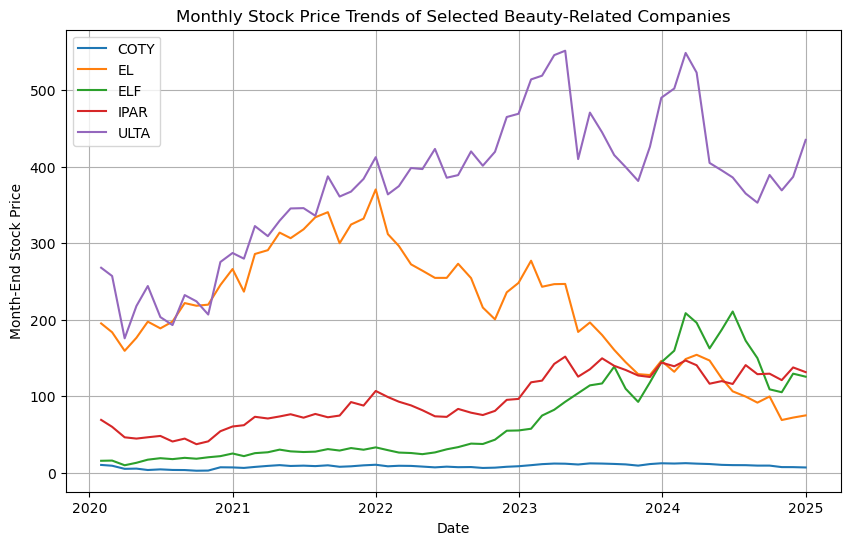

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for ticker in clean_data['ticker'].unique():
    company_data = clean_data[clean_data['ticker'] == ticker]
    plt.plot(company_data['date'], company_data['prc'], label=ticker)

plt.title("Monthly Stock Price Trends of Selected Beauty-Related Companies")
plt.xlabel("Date")
plt.ylabel("Month-End Stock Price")
plt.legend()
plt.grid(True)
plt.savefig("figures/stock_price_trends.png", bbox_inches="tight")
plt.show()

The chart provides an initial view of monthly stock price movements for the five selected companies. However, stock price levels are not directly comparable across companies because each company has a different share price scale. Therefore, cumulative returns and volatility will be analysed in the following sections to provide a more meaningful risk-return comparison.

### 5.2 Cumulative Return Comparison

This section calculates cumulative returns using monthly stock returns. Unlike stock price levels, cumulative returns allow a more meaningful comparison of investment performance across companies with different share price scales.

In [9]:
# Calculate cumulative returns for each company
clean_data['cumulative_return'] = (
    clean_data.groupby('ticker')['ret']
    .transform(lambda x: (1 + x).cumprod() - 1)
)

clean_data[['date', 'ticker', 'ret', 'cumulative_return']].head()

,date,ticker,ret,cumulative_return
0,2020-01-31,COTY,-0.088000,-0.088000
1,2020-02-28,COTY,-0.088207,-0.168445
2,2020-03-31,COTY,-0.440953,-0.535122
3,2020-04-30,COTY,0.056202,-0.508994
4,2020-05-29,COTY,-0.333945,-0.672963


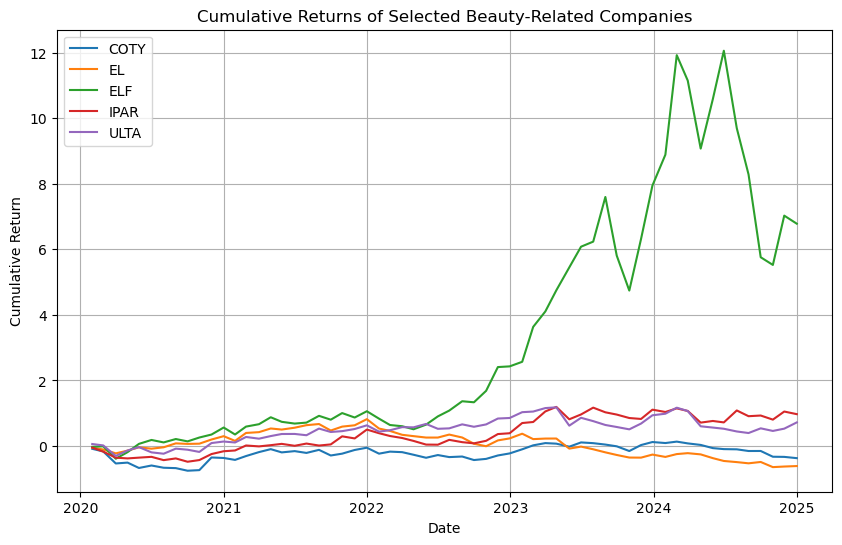

In [18]:
plt.figure(figsize=(10, 6))

for ticker in clean_data['ticker'].unique():
    company_data = clean_data[clean_data['ticker'] == ticker]
    plt.plot(company_data['date'], company_data['cumulative_return'], label=ticker)

plt.title("Cumulative Returns of Selected Beauty-Related Companies")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.savefig("figures/cumulative_returns.png", bbox_inches="tight")
plt.show()

The cumulative return chart gives a more useful comparison than the stock price chart, because it shows the percentage change over the whole period.

The most obvious result is ELF. After 2022, its cumulative return increased much faster than the other companies. The other four companies did not show such a large increase and stayed in a lower range.

However, this does not mean ELF is definitely the best choice. This chart only shows return, but not the level of risk. If the stock also had large fluctuations, then the higher return came with higher risk. Therefore, I need to compare volatility next.

### 5.3 Volatility and Risk Comparison

This section compares the volatility of monthly returns for the five companies. In this project, volatility is measured by the standard deviation of monthly returns. A higher volatility means that the stock return changed more sharply from month to month, which indicates higher historical risk.

In [12]:
# Calculate average monthly return and volatility for each company
risk_return_summary = clean_data.groupby('ticker').agg(
    company_name=('comnam', 'first'),
    average_monthly_return=('ret', 'mean'),
    volatility=('ret', 'std'),
    final_cumulative_return=('cumulative_return', 'last')
)

risk_return_summary

,company_name,average_monthly_return,volatility,final_cumulative_return
ticker,,,,
COTY,COTY INC,0.011624,0.234213,-0.372954
EL,LAUDER ESTEE COS INC,-0.010147,0.104304,-0.614239
ELF,E L F BEAUTY INC,0.046018,0.149985,6.783644
IPAR,INTERMEDIATE PARFUMS INC,0.017534,0.113954,0.969551
ULTA,ULTA BEAUTY INC,0.015240,0.110643,0.718134


In [21]:
# Convert return measures into percentage format for easier interpretation
summary_percent = risk_return_summary.copy()

summary_percent['average_monthly_return'] = summary_percent['average_monthly_return'] * 100
summary_percent['volatility'] = summary_percent['volatility'] * 100
summary_percent['final_cumulative_return'] = summary_percent['final_cumulative_return'] * 100

summary_percent = summary_percent.round(2)

summary_percent.to_csv("figures/risk_return_summary.csv")
print("Risk-return summary saved successfully")

summary_percent

Risk-return summary saved successfully


,company_name,average_monthly_return,volatility,final_cumulative_return
ticker,,,,
COTY,COTY INC,1.16,23.42,-37.30
EL,LAUDER ESTEE COS INC,-1.01,10.43,-61.42
ELF,E L F BEAUTY INC,4.60,15.00,678.36
IPAR,INTERMEDIATE PARFUMS INC,1.75,11.40,96.96
ULTA,ULTA BEAUTY INC,1.52,11.06,71.81


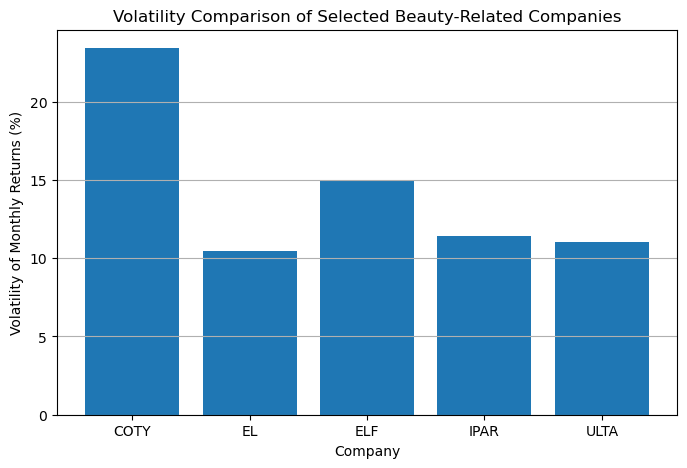

In [19]:
# Plot volatility comparison
plt.figure(figsize=(8, 5))

plt.bar(summary_percent.index, summary_percent['volatility'])

plt.title("Volatility Comparison of Selected Beauty-Related Companies")
plt.xlabel("Company")
plt.ylabel("Volatility of Monthly Returns (%)")
plt.grid(axis='y')
plt.savefig("figures/volatility_comparison.png", bbox_inches="tight")
plt.show()

The volatility chart shows that COTY had the highest monthly return volatility, around 23%. This means COTY had the largest month-to-month fluctuation among the five companies, so it carried the highest historical risk in this sample.

ELF also had relatively high volatility, around 15%. When this is compared with the cumulative return result, ELF appears to have the strongest risk-return profile: it had the highest cumulative return, while its volatility was high but not the highest. This suggests that ELF provided much stronger return for the level of risk taken compared with the other companies.

EL had the lowest volatility, but its final cumulative return was negative. This shows that lower volatility did not necessarily lead to better performance. Overall, the results suggest that return and risk should be considered together, rather than judging the companies only by price movement or return.

### 5.4 Risk-Return Summary

This section combines average monthly return and volatility in one chart. The purpose is to compare whether companies with higher returns also had higher risk during the sample period.

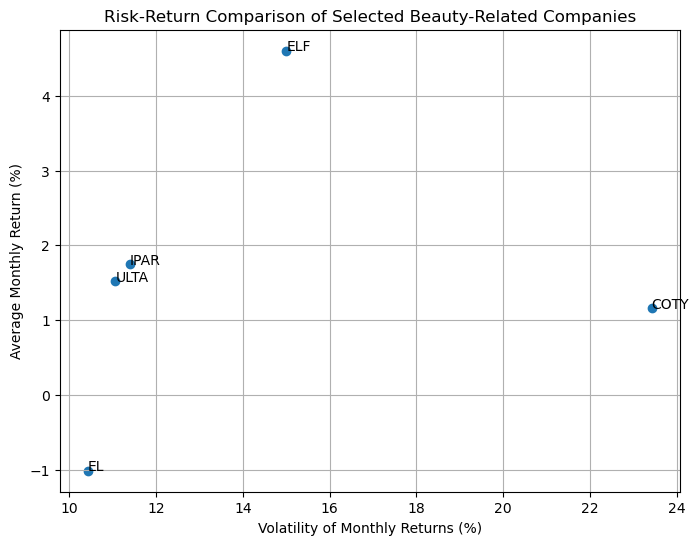

In [20]:
# Plot risk-return relationship
plt.figure(figsize=(8, 6))

plt.scatter(
    summary_percent['volatility'],
    summary_percent['average_monthly_return']
)

for ticker in summary_percent.index:
    plt.text(
        summary_percent.loc[ticker, 'volatility'],
        summary_percent.loc[ticker, 'average_monthly_return'],
        ticker
    )

plt.title("Risk-Return Comparison of Selected Beauty-Related Companies")
plt.xlabel("Volatility of Monthly Returns (%)")
plt.ylabel("Average Monthly Return (%)")
plt.grid(True)
plt.savefig("figures/risk_return_scatter.png", bbox_inches="tight")
plt.show()

The scatter plot suggests that ELF has the best risk-return result among the five companies in this sample. Although ELF has relatively high volatility, its average monthly return is much higher than the others, and its volatility is still lower than COTY. Therefore, the higher risk taken by ELF seems to be rewarded by much stronger return.

COTY has the weakest risk-return result. It has the highest volatility, but its average monthly return is only slightly pos|itive and its final cumulative return is negative. This means that COTY had high fluctuation without strong return compensation during the sample period.

IPAR and ULTA look more stable than ELF and COTY. They have moderate volatility and positive returns, so they may be seen as more balanced cases. However, their return levels are much lower than ELF. EL has the lowest volatility, but its negative average return means that low volatility alone did not lead to good performance.

Overall, the main conclusion is that ELF performed best from a risk-return perspective, while COTY performed worst. The comparison also shows why return and risk need to be analysed together: the company with the highest return was not the riskiest, and the company with the highest risk did not produce the best return.

## 6. Limitations

This project has several limitations. First, the analysis only uses five selected beauty-related companies, so the result cannot represent the whole beauty or consumer sector. The sample is useful for comparison, but it is still limited in size.

Second, the project mainly uses monthly stock price and return data from WRDS. These data can show historical risk and return patterns, but they do not explain all the reasons behind the stock movements. For example, company earnings, product launches, marketing strategies, and wider market conditions may also affect stock performance.

Third, the analysis is based on historical data from January 2020 to December 2024. The results can describe what happened in this period, but they should not be treated as a prediction of future stock performance.

Finally, this project uses simple risk-return indicators, including average monthly return, cumulative return, and volatility. These indicators are useful for beginner-level comparison, but they do not fully capture all types of investment risk.

## 7. Conclusion

This project compared the historical risk and return performance of five beauty-related companies using monthly stock data from WRDS. The analysis used stock price trends, cumulative returns, average monthly returns, and volatility to compare the companies from different perspectives.

The main finding is that ELF had the strongest performance in this sample. It had the highest cumulative return and the highest average monthly return, while its volatility was high but not the highest. In contrast, COTY had the highest volatility but did not achieve a strong return outcome, which made its risk-return result weaker.

IPAR and ULTA showed more moderate results, with positive returns and lower volatility than ELF and COTY. EL had the lowest volatility, but its return performance was negative over the sample period. Overall, the results show that return and risk need to be considered together. A lower-risk stock does not always perform better, and a higher-risk stock does not always provide stronger returns.